# 5x5 Activity PRC -- all datasets

Aggregated precision-recall / ROC results from 5x5 activity simulations
(5 ground-truth draws x 5 simulation replicates, 70% inactive).

**Canonical models:**
- Shendure: obs NB
- Cohen: obsingle NB
- Seelig: CM NB

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path(".")

DATASETS = {
    "Shendure (obs NB)": ROOT / "shendure" / "output" / "shendure_5x5_activity_summary.tsv",
    "Cohen (obsingle NB)": ROOT / "cohen" / "output" / "cohen_5x5_activity_summary.tsv",
    "Seelig (CM NB)": ROOT / "seelig" / "output" / "seelig_5x5_activity_summary.tsv",
}

dfs = {}
for name, path in DATASETS.items():
    if path.exists():
        dfs[name] = pd.read_csv(path, sep="\t")
    else:
        print(f"Missing: {name} ({path})")

print(f"Loaded {len(dfs)}/{len(DATASETS)} datasets")

Missing: Seelig (CM NB) (seelig/output/seelig_5x5_activity_summary.tsv)
Loaded 2/3 datasets


## Summary table: mean +/- std across all 25 replicates

In [2]:
rows = []
for name, df in dfs.items():
    for test in df["test"].unique():
        sub = df[df["test"] == test]
        rows.append({
            "Dataset": name,
            "Test": test,
            "AUROC": f"{sub['auroc'].mean():.3f} +/- {sub['auroc'].std():.3f}",
            "AUPRC": f"{sub['auprc'].mean():.3f} +/- {sub['auprc'].std():.3f}",
            "n": len(sub),
        })

summary = pd.DataFrame(rows)
summary

,Dataset,Test,AUROC,AUPRC,n
0,Shendure (obs NB),mwu,0.922 +/- 0.012,0.914 +/- 0.013,25
1,Shendure (obs NB),wald_auto,0.923 +/- 0.012,0.914 +/- 0.012,25
2,Cohen (obsingle NB),mwu,0.880 +/- 0.028,0.863 +/- 0.028,25
3,Cohen (obsingle NB),wald_auto,0.751 +/- 0.133,0.649 +/- 0.221,25


## Per-GT-draw breakdown

Shows variance across GT draws (biological resampling) vs within-draw
(technical resampling). Large between-draw variance suggests sensitivity
to the specific ground truth partition.

In [3]:
for name, df in dfs.items():
    print(f"\n=== {name} ===")
    gt_summary = (
        df.groupby(["test", "gt_draw"])
        .agg(auroc_mean=("auroc", "mean"), auroc_std=("auroc", "std"),
             auprc_mean=("auprc", "mean"), auprc_std=("auprc", "std"),
             n=("replicate", "count"))
        .reset_index()
    )
    for test in gt_summary["test"].unique():
        sub = gt_summary[gt_summary["test"] == test]
        print(f"\n  {test}:")
        for _, row in sub.iterrows():
            print(f"    GT {int(row['gt_draw'])}: AUROC={row['auroc_mean']:.3f}+/-{row['auroc_std']:.3f}  "
                  f"AUPRC={row['auprc_mean']:.3f}+/-{row['auprc_std']:.3f}")
        means = sub["auroc_mean"]
        print(f"    between-draw spread: {means.max() - means.min():.3f}")


=== Shendure (obs NB) ===

  mwu:
    GT 0: AUROC=0.925+/-0.015  AUPRC=0.916+/-0.014
    GT 1: AUROC=0.927+/-0.004  AUPRC=0.921+/-0.003
    GT 2: AUROC=0.925+/-0.012  AUPRC=0.915+/-0.019
    GT 3: AUROC=0.915+/-0.014  AUPRC=0.906+/-0.015
    GT 4: AUROC=0.920+/-0.008  AUPRC=0.910+/-0.009
    between-draw spread: 0.013

  wald_auto:
    GT 0: AUROC=0.927+/-0.017  AUPRC=0.919+/-0.016
    GT 1: AUROC=0.925+/-0.006  AUPRC=0.919+/-0.005
    GT 2: AUROC=0.929+/-0.005  AUPRC=0.922+/-0.007
    GT 3: AUROC=0.915+/-0.014  AUPRC=0.906+/-0.016
    GT 4: AUROC=0.918+/-0.009  AUPRC=0.906+/-0.007
    between-draw spread: 0.014

=== Cohen (obsingle NB) ===

  mwu:
    GT 0: AUROC=0.895+/-0.025  AUPRC=0.869+/-0.018
    GT 1: AUROC=0.871+/-0.023  AUPRC=0.859+/-0.025
    GT 2: AUROC=0.874+/-0.015  AUPRC=0.868+/-0.013
    GT 3: AUROC=0.872+/-0.045  AUPRC=0.844+/-0.049
    GT 4: AUROC=0.888+/-0.026  AUPRC=0.874+/-0.021
    between-draw spread: 0.024

  wald_auto:
    GT 0: AUROC=0.829+/-0.068  AUPRC=0.747

## AUROC by dataset and test

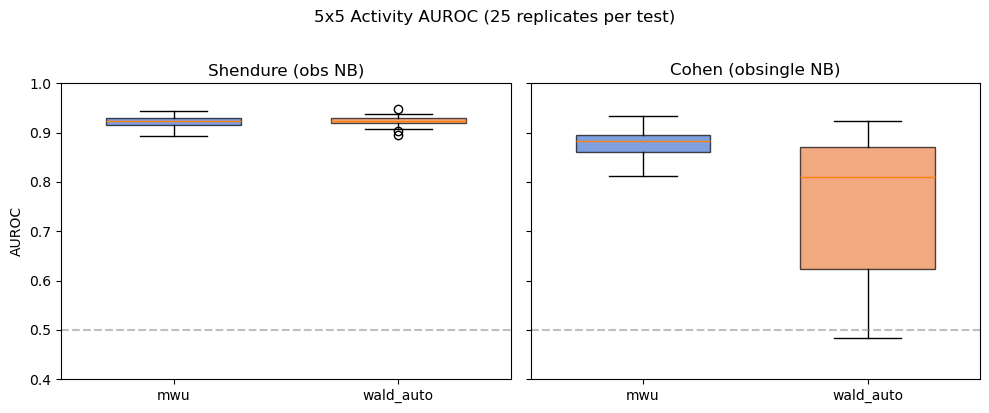

In [4]:
fig, axes = plt.subplots(1, len(dfs), figsize=(5 * len(dfs), 4), sharey=True)
if len(dfs) == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, dfs.items()):
    tests = sorted(df["test"].unique())
    positions = range(len(tests))
    for i, test in enumerate(tests):
        sub = df[df["test"] == test]
        ax.boxplot(sub["auroc"], positions=[i], widths=0.6,
                   patch_artist=True,
                   boxprops=dict(facecolor=["#4878d0", "#ee854a"][i % 2], alpha=0.7))
    ax.set_xticks(positions)
    ax.set_xticklabels(tests)
    ax.set_title(name)
    ax.set_ylim(0.4, 1.0)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)

axes[0].set_ylabel("AUROC")
fig.suptitle("5x5 Activity AUROC (25 replicates per test)", y=1.02)
fig.tight_layout()
plt.show()

## AUPRC by dataset and test

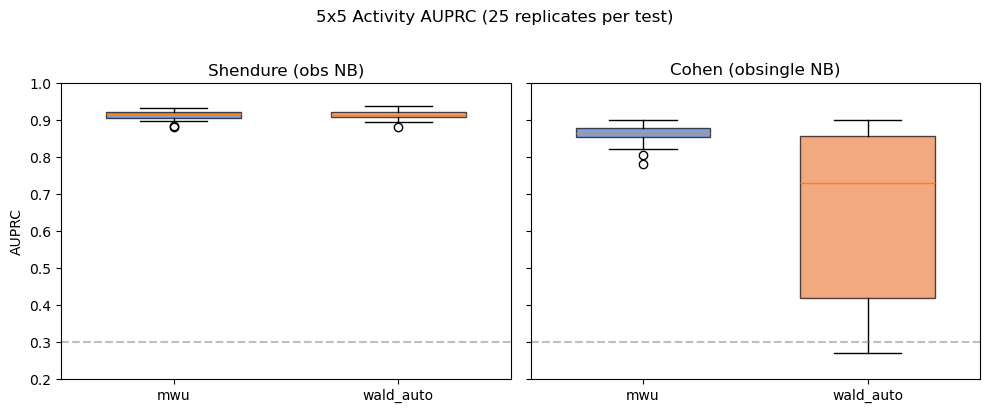

In [5]:
fig, axes = plt.subplots(1, len(dfs), figsize=(5 * len(dfs), 4), sharey=True)
if len(dfs) == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, dfs.items()):
    tests = sorted(df["test"].unique())
    positions = range(len(tests))
    for i, test in enumerate(tests):
        sub = df[df["test"] == test]
        ax.boxplot(sub["auprc"], positions=[i], widths=0.6,
                   patch_artist=True,
                   boxprops=dict(facecolor=["#4878d0", "#ee854a"][i % 2], alpha=0.7))
    ax.set_xticks(positions)
    ax.set_xticklabels(tests)
    ax.set_title(name)
    ax.set_ylim(0.2, 1.0)
    ax.axhline(0.3, color="gray", linestyle="--", alpha=0.5, label="30% baseline")

axes[0].set_ylabel("AUPRC")
fig.suptitle("5x5 Activity AUPRC (25 replicates per test)", y=1.02)
fig.tight_layout()
plt.show()

## AUROC by GT draw (variance decomposition)

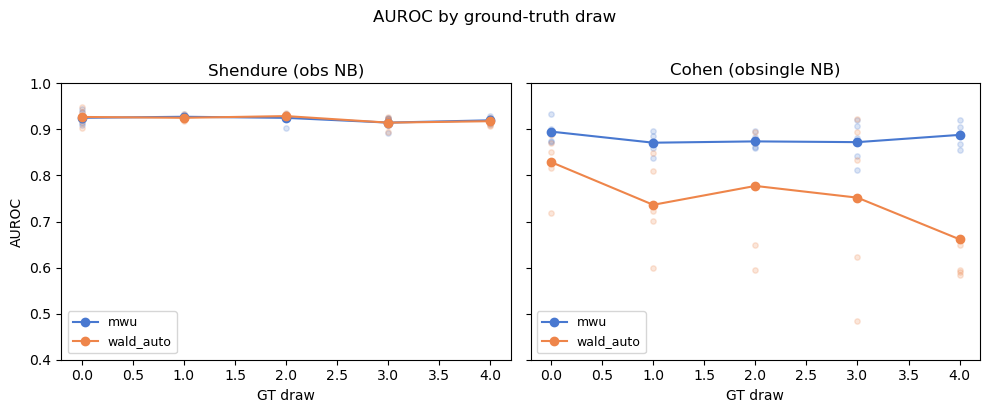

In [6]:
fig, axes = plt.subplots(1, len(dfs), figsize=(5 * len(dfs), 4), sharey=True)
if len(dfs) == 1:
    axes = [axes]

colors = {"mwu": "#4878d0", "wald_auto": "#ee854a"}

for ax, (name, df) in zip(axes, dfs.items()):
    for test in sorted(df["test"].unique()):
        sub = df[df["test"] == test]
        gt_means = sub.groupby("gt_draw")["auroc"].mean()
        ax.plot(gt_means.index, gt_means.values, "o-",
                color=colors.get(test, "gray"), label=test, markersize=6)
        # show individual reps as faint dots
        ax.scatter(sub["gt_draw"], sub["auroc"], color=colors.get(test, "gray"),
                   alpha=0.2, s=15)
    ax.set_xlabel("GT draw")
    ax.set_title(name)
    ax.set_ylim(0.4, 1.0)
    ax.legend(fontsize=9)

axes[0].set_ylabel("AUROC")
fig.suptitle("AUROC by ground-truth draw", y=1.02)
fig.tight_layout()
plt.show()